# Flash Flood Data Exploration – Liguria, Italy

## Project: Italy Natural Hazard Intelligence

This notebook explores environmental and hydro-meteorological data related to flash flood hazards in Liguria, Italy.

### Objectives
- Load and inspect the dataset
- Understand the structure of the data
- Identify missing values
- Perform basic statistical analysis
- Visualize important variables

In [8]:
import pandas as pd

openmeteo_path = "../data/raw/open-meteo-44.46N8.97E11m.csv"

df_openmeteo = pd.read_csv(openmeteo_path)

df_openmeteo.head()

ParserError: Error tokenizing data. C error: Expected 6 fields in line 4, saw 7


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

file_path = "../data/raw/40777765150469.csv"

df = pd.read_csv(file_path)

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xec in position 222: invalid continuation byte

In [ ]:
import pandas as pd

file_path = "../data/raw/40777765150469.csv"

df = pd.read_csv(file_path, encoding="latin1")

df.head()

ParserError: Error tokenizing data. C error: Expected 2 fields in line 6, saw 5


In [ ]:
import pandas as pd

file_path = "../data/raw/40777765150469.csv"

df = pd.read_csv(file_path, encoding="latin1")

df.head()

ParserError: Error tokenizing data. C error: Expected 2 fields in line 6, saw 5


In [ ]:
file_path = "../data/raw/40777765150469.csv"

with open(file_path, "r", encoding="latin1") as f:
    for i in range(20):
        print(f.readline())





"Stazione",GENOVA - GEIRATO

"Parametro",PRECIPITAZIONE - PRECIPITAZIONE CUMULATA (mm)



"Inizio rilevazione","Fine rilevazione","Valore","Dataset","Valido"

"08/10/2014 00:00","08/10/2014 01:00","0","Tutti i dati","Sì"

"08/10/2014 01:00","08/10/2014 02:00","0","Tutti i dati","Sì"

"08/10/2014 02:00","08/10/2014 03:00","0","Tutti i dati","Sì"

"08/10/2014 03:00","08/10/2014 04:00",".6","Tutti i dati","Sì"

"08/10/2014 04:00","08/10/2014 05:00","0","Tutti i dati","Sì"

"08/10/2014 05:00","08/10/2014 06:00","0","Tutti i dati","Sì"

"08/10/2014 06:00","08/10/2014 07:00","0","Tutti i dati","Sì"

"08/10/2014 07:00","08/10/2014 08:00","0","Tutti i dati","Sì"

"08/10/2014 08:00","08/10/2014 09:00","0","Tutti i dati","Sì"

"08/10/2014 09:00","08/10/2014 10:00","2.8","Tutti i dati","Sì"

"08/10/2014 10:00","08/10/2014 11:00","6.6","Tutti i dati","Sì"

"08/10/2014 11:00","08/10/2014 12:00","4.6","Tutti i dati","Sì"

"08/10/2014 12:00","08/10/2014 13:00","0","Tutti i dati","Sì"

"08/10/2014

In [ ]:
import pandas as pd

file_path = "../data/raw/40777765150469.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1",
    skiprows=4
)

df.head()

,Inizio rilevazione,Fine rilevazione,Valore,Dataset,Valido
0,08/10/2014 00:00,08/10/2014 01:00,0.0,Tutti i dati,Sì
1,08/10/2014 01:00,08/10/2014 02:00,0.0,Tutti i dati,Sì
2,08/10/2014 02:00,08/10/2014 03:00,0.0,Tutti i dati,Sì
3,08/10/2014 03:00,08/10/2014 04:00,0.6,Tutti i dati,Sì
4,08/10/2014 04:00,08/10/2014 05:00,0.0,Tutti i dati,Sì


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Inizio rilevazione  109 non-null    str    
 1   Fine rilevazione    109 non-null    str    
 2   Valore              107 non-null    float64
 3   Dataset             107 non-null    str    
 4   Valido              107 non-null    str    
dtypes: float64(1), str(4)
memory usage: 4.4 KB


In [ ]:
df.describe()

,Valore
count,107.000000
mean,6.456075
std,17.553945
min,0.000000
25%,0.000000
50%,0.000000
75%,2.200000
max,135.000000


In [ ]:
df.tail()

,Inizio rilevazione,Fine rilevazione,Valore,Dataset,Valido
104,12/10/2014 18:00,12/10/2014 19:00,0.0,Tutti i dati,Sì
105,12/10/2014 21:00,12/10/2014 22:00,0.2,Tutti i dati,Sì
106,12/10/2014 23:00,13/10/2014 00:00,0.0,Tutti i dati,Sì
107,Dati letti,107,NaN,NaN,NaN
108,Dati validi,107,NaN,NaN,NaN


In [ ]:
df = df.iloc[:-2]

df.tail()

,Inizio rilevazione,Fine rilevazione,Valore,Dataset,Valido
102,12/10/2014 12:00,12/10/2014 13:00,0.0,Tutti i dati,Sì
103,12/10/2014 14:00,12/10/2014 15:00,0.0,Tutti i dati,Sì
104,12/10/2014 18:00,12/10/2014 19:00,0.0,Tutti i dati,Sì
105,12/10/2014 21:00,12/10/2014 22:00,0.2,Tutti i dati,Sì
106,12/10/2014 23:00,13/10/2014 00:00,0.0,Tutti i dati,Sì


In [ ]:
df["Inizio rilevazione"] = pd.to_datetime(
    df["Inizio rilevazione"],
    format="%d/%m/%Y %H:%M"
)

df["Fine rilevazione"] = pd.to_datetime(
    df["Fine rilevazione"],
    format="%d/%m/%Y %H:%M"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Inizio rilevazione  107 non-null    datetime64[us]
 1   Fine rilevazione    107 non-null    datetime64[us]
 2   Valore              107 non-null    float64       
 3   Dataset             107 non-null    str           
 4   Valido              107 non-null    str           
dtypes: datetime64[us](2), float64(1), str(2)
memory usage: 4.3 KB


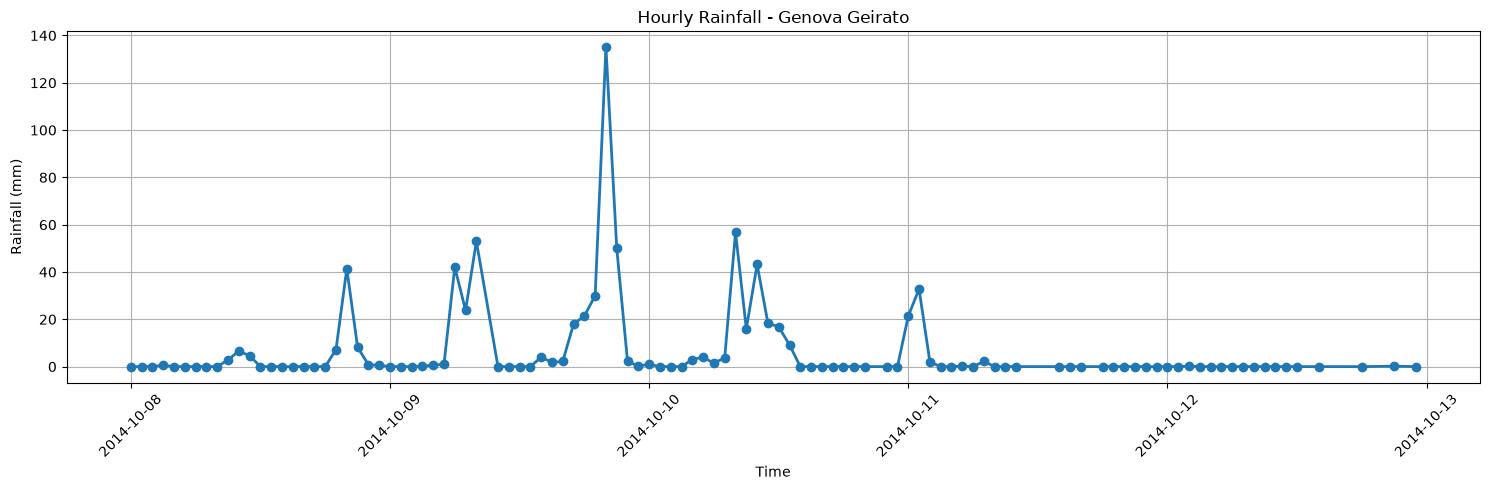

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df["Inizio rilevazione"],
    df["Valore"],
    marker="o",
    linewidth=2
)

plt.title("Hourly Rainfall - Genova Geirato")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.loc[df["Valore"].idxmax()]

Inizio rilevazione    2014-10-09 20:00:00
Fine rilevazione      2014-10-09 21:00:00
Valore                              135.0
Dataset                      Tutti i dati
Valido                                 Sì
Name: 43, dtype: object

In [ ]:
print("Maximum rainfall:", df["Valore"].max(), "mm")
print("Mean rainfall:", df["Valore"].mean(), "mm")
print("Total rainfall:", df["Valore"].sum(), "mm")

Maximum rainfall: 135.0 mm
Mean rainfall: 6.456074766355141 mm
Total rainfall: 690.8000000000001 mm


In [16]:
import pandas as pd

openmeteo_path = "../data/raw/open-meteo-44.46N8.97E11m.csv"

df_openmeteo = pd.read_csv(
    openmeteo_path,
    skiprows=2
)

df_openmeteo.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),pressure_msl (hPa)
0,2014-10-08T00:00,17.1,96,1.0,1.0,2.1,1017.4
1,2014-10-08T01:00,17.0,97,1.3,1.3,3.1,1017.8
2,2014-10-08T02:00,16.9,97,1.5,1.5,2.9,1017.9
3,2014-10-08T03:00,16.6,98,1.5,1.5,4.1,1017.4
4,2014-10-08T04:00,16.6,98,1.5,1.5,3.8,1017.2


In [ ]:
df_openmeteo.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      120 non-null    str    
 1   temperature_2m (°C)       120 non-null    float64
 2   relative_humidity_2m (%)  120 non-null    int64  
 3   precipitation (mm)        120 non-null    float64
 4   rain (mm)                 120 non-null    float64
 5   wind_speed_10m (km/h)     120 non-null    float64
 6   pressure_msl (hPa)        120 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 6.7 KB


In [ ]:
df_openmeteo["time"] = pd.to_datetime(df_openmeteo["time"])

df_openmeteo.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   time                      120 non-null    datetime64[us]
 1   temperature_2m (°C)       120 non-null    float64       
 2   relative_humidity_2m (%)  120 non-null    int64         
 3   precipitation (mm)        120 non-null    float64       
 4   rain (mm)                 120 non-null    float64       
 5   wind_speed_10m (km/h)     120 non-null    float64       
 6   pressure_msl (hPa)        120 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 6.7 KB


In [13]:
arpal_path = "../data/raw/40777765150469.csv"

df_arpal = pd.read_csv(
    arpal_path,
    encoding="latin1",
    skiprows=5
)

df_arpal.head()

,Inizio rilevazione,Fine rilevazione,Valore,Dataset,Valido
0,08/10/2014 00:00,08/10/2014 01:00,0.0,Tutti i dati,Sì
1,08/10/2014 01:00,08/10/2014 02:00,0.0,Tutti i dati,Sì
2,08/10/2014 02:00,08/10/2014 03:00,0.0,Tutti i dati,Sì
3,08/10/2014 03:00,08/10/2014 04:00,0.6,Tutti i dati,Sì
4,08/10/2014 04:00,08/10/2014 05:00,0.0,Tutti i dati,Sì


In [14]:
df_arpal["Inizio rilevazione"] = pd.to_datetime(
    df_arpal["Inizio rilevazione"],
    dayfirst=True,
    errors="coerce"
)

df_arpal["Fine rilevazione"] = pd.to_datetime(
    df_arpal["Fine rilevazione"],
    dayfirst=True,
    errors="coerce"
)

df_arpal = df_arpal.dropna(
    subset=["Inizio rilevazione", "Fine rilevazione"]
)

df_arpal.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Inizio rilevazione  107 non-null    datetime64[us]
 1   Fine rilevazione    107 non-null    datetime64[us]
 2   Valore              107 non-null    float64       
 3   Dataset             107 non-null    str           
 4   Valido              107 non-null    str           
dtypes: datetime64[us](2), float64(1), str(2)
memory usage: 4.3 KB


In [ ]:
df_openmeteo["time"] = pd.to_datetime(df_openmeteo["time"])

df_openmeteo.info()


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   time                      120 non-null    datetime64[us]
 1   temperature_2m (°C)       120 non-null    float64       
 2   relative_humidity_2m (%)  120 non-null    int64         
 3   precipitation (mm)        120 non-null    float64       
 4   rain (mm)                 120 non-null    float64       
 5   wind_speed_10m (km/h)     120 non-null    float64       
 6   pressure_msl (hPa)        120 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 6.7 KB


In [ ]:
df_arpal_compare = df_arpal[
    ["Inizio rilevazione", "Valore"]
].copy()

df_arpal_compare = df_arpal_compare.rename(
    columns={
        "Inizio rilevazione": "time",
        "Valore": "arpal_precipitation_mm"
    }
)

df_arpal_compare.head()

,time,arpal_precipitation_mm
0,2014-10-08 00:00:00,0.0
1,2014-10-08 01:00:00,0.0
2,2014-10-08 02:00:00,0.0
3,2014-10-08 03:00:00,0.6
4,2014-10-08 04:00:00,0.0


In [ ]:
df_openmeteo_compare = df_openmeteo[
    ["time", "precipitation (mm)"]
].copy()

df_openmeteo_compare = df_openmeteo_compare.rename(
    columns={
        "precipitation (mm)": "openmeteo_precipitation_mm"
    }
)

df_openmeteo_compare.head()

,time,openmeteo_precipitation_mm
0,2014-10-08 00:00:00,1.0
1,2014-10-08 01:00:00,1.3
2,2014-10-08 02:00:00,1.5
3,2014-10-08 03:00:00,1.5
4,2014-10-08 04:00:00,1.5


In [ ]:
df_compare = pd.merge(
    df_arpal_compare,
    df_openmeteo_compare,
    on="time",
    how="inner"
)

df_compare.head()

,time,arpal_precipitation_mm,openmeteo_precipitation_mm
0,2014-10-08 00:00:00,0.0,1.0
1,2014-10-08 01:00:00,0.0,1.3
2,2014-10-08 02:00:00,0.0,1.5
3,2014-10-08 03:00:00,0.6,1.5
4,2014-10-08 04:00:00,0.0,1.5


In [ ]:
print("Number of matched hours:", len(df_compare))

print("\nDate range:")
print(df_compare["time"].min(), "to", df_compare["time"].max())

print("\nMissing values:")
print(df_compare.isna().sum())

Number of matched hours: 107

Date range:
2014-10-08 00:00:00 to 2014-10-12 23:00:00

Missing values:
time                          0
arpal_precipitation_mm        0
openmeteo_precipitation_mm    0
dtype: int64


In [ ]:
print("ARPAL precipitation statistics:")
print(df_compare["arpal_precipitation_mm"].describe())

print("\nOpen-Meteo precipitation statistics:")
print(df_compare["openmeteo_precipitation_mm"].describe())

ARPAL precipitation statistics:
count    107.000000
mean       6.456075
std       17.553945
min        0.000000
25%        0.000000
50%        0.000000
75%        2.200000
max      135.000000
Name: arpal_precipitation_mm, dtype: float64

Open-Meteo precipitation statistics:
count    107.000000
mean       0.903738
std        0.791097
min        0.000000
25%        0.300000
50%        0.700000
75%        1.350000
max        3.800000
Name: openmeteo_precipitation_mm, dtype: float64


In [ ]:
df_compare["difference_mm"] = (
    df_compare["arpal_precipitation_mm"]
    - df_compare["openmeteo_precipitation_mm"]
)

df_compare["absolute_error_mm"] = (
    df_compare["difference_mm"].abs()
)

df_compare.head()

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08 00:00:00,0.0,1.0,-1.0,1.0
1,2014-10-08 01:00:00,0.0,1.3,-1.3,1.3
2,2014-10-08 02:00:00,0.0,1.5,-1.5,1.5
3,2014-10-08 03:00:00,0.6,1.5,-0.9,0.9
4,2014-10-08 04:00:00,0.0,1.5,-1.5,1.5


In [ ]:
largest_errors = df_compare.sort_values(
    "absolute_error_mm",
    ascending=False
)

largest_errors[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm",
        "absolute_error_mm"
    ]
].head(10)

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
43,2014-10-09 20:00:00,135.0,1.3,133.7,133.7
55,2014-10-10 08:00:00,56.8,0.6,56.2,56.2
32,2014-10-09 08:00:00,53.0,2.6,50.4,50.4
44,2014-10-09 21:00:00,50.0,1.8,48.2,48.2
57,2014-10-10 10:00:00,43.2,0.5,42.7,42.7
20,2014-10-08 20:00:00,41.4,0.6,40.8,40.8
30,2014-10-09 06:00:00,42.0,1.2,40.8,40.8
71,2014-10-11 01:00:00,32.8,0.5,32.3,32.3
42,2014-10-09 19:00:00,30.0,1.0,29.0,29.0
31,2014-10-09 07:00:00,23.8,1.8,22.0,22.0


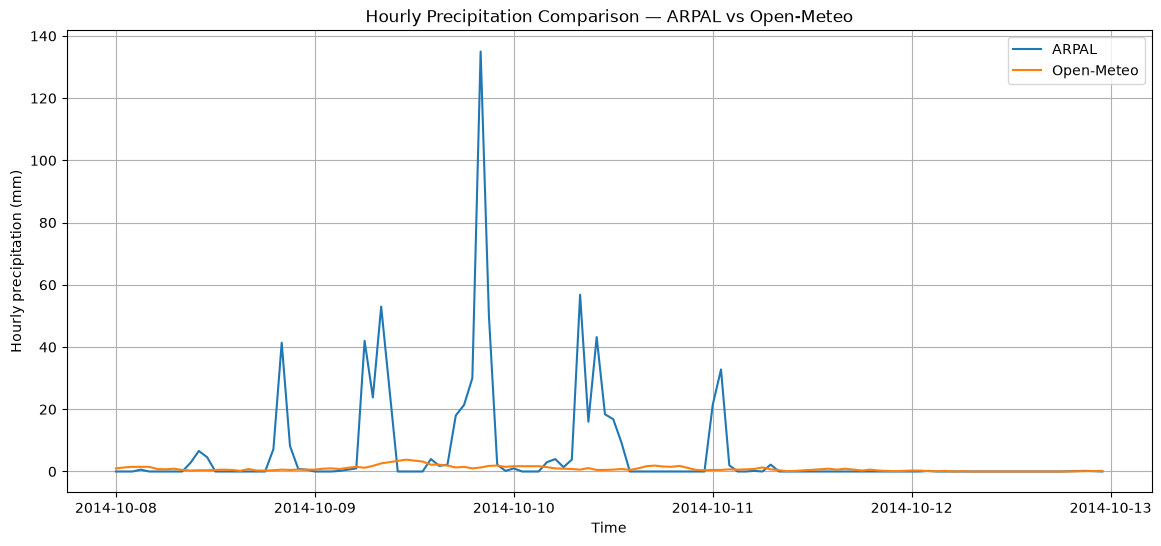

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df_compare["time"],
    df_compare["arpal_precipitation_mm"],
    label="ARPAL"
)

plt.plot(
    df_compare["time"],
    df_compare["openmeteo_precipitation_mm"],
    label="Open-Meteo"
)

plt.xlabel("Time")
plt.ylabel("Hourly precipitation (mm)")
plt.title("Hourly Precipitation Comparison — ARPAL vs Open-Meteo")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
mae = df_compare["absolute_error_mm"].mean()

print(f"Mean Absolute Error (MAE): {mae:.2f} mm")

Mean Absolute Error (MAE): 6.64 mm


In [ ]:
bias = df_compare["difference_mm"].mean()

print(f"Mean Bias: {bias:.2f} mm")

Mean Bias: 5.55 mm


In [ ]:
import numpy as np

rmse = np.sqrt(
    np.mean(df_compare["difference_mm"] ** 2)
)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} mm")

Root Mean Squared Error (RMSE): 18.27 mm


In [ ]:
rainy_hours = df_compare[
    df_compare["arpal_precipitation_mm"] > 0
].copy()

print("Rainy hours:", len(rainy_hours))

print("\nMAE during rainy hours:")
print(
    rainy_hours["absolute_error_mm"].mean()
)

print("\nMean ARPAL precipitation during rainy hours:")
print(
    rainy_hours["arpal_precipitation_mm"].mean()
)

print("\nMean Open-Meteo precipitation during rainy hours:")
print(
    rainy_hours["openmeteo_precipitation_mm"].mean()
)

Rainy hours: 43

MAE during rainy hours:
15.295348837209303

Mean ARPAL precipitation during rainy hours:
16.065116279069773

Mean Open-Meteo precipitation during rainy hours:
1.030232558139535


In [ ]:
extreme_events = df_compare[
    df_compare["arpal_precipitation_mm"] >= 20
].copy()

print("Number of extreme rainfall hours:", len(extreme_events))

print("\nExtreme rainfall events:")
print(
    extreme_events[
        [
            "time",
            "arpal_precipitation_mm",
            "openmeteo_precipitation_mm",
            "difference_mm"
        ]
    ].sort_values(
        "arpal_precipitation_mm",
        ascending=False
    )
)

Number of extreme rainfall hours: 12

Extreme rainfall events:
                  time  arpal_precipitation_mm  openmeteo_precipitation_mm  \
43 2014-10-09 20:00:00                   135.0                         1.3   
55 2014-10-10 08:00:00                    56.8                         0.6   
32 2014-10-09 08:00:00                    53.0                         2.6   
44 2014-10-09 21:00:00                    50.0                         1.8   
57 2014-10-10 10:00:00                    43.2                         0.5   
30 2014-10-09 06:00:00                    42.0                         1.2   
20 2014-10-08 20:00:00                    41.4                         0.6   
71 2014-10-11 01:00:00                    32.8                         0.5   
42 2014-10-09 19:00:00                    30.0                         1.0   
31 2014-10-09 07:00:00                    23.8                         1.8   
41 2014-10-09 18:00:00                    21.4                         1.5   
7

In [ ]:
oct9 = df_compare[
    df_compare["time"].dt.date == pd.Timestamp("2014-10-09").date()
].copy()

oct9[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm"
    ]
]

,time,arpal_precipitation_mm,openmeteo_precipitation_mm
24,2014-10-09 00:00:00,0.0,0.6
25,2014-10-09 01:00:00,0.0,0.9
26,2014-10-09 02:00:00,0.0,1.0
27,2014-10-09 03:00:00,0.2,0.8
28,2014-10-09 04:00:00,0.6,1.2
29,2014-10-09 05:00:00,1.0,1.5
30,2014-10-09 06:00:00,42.0,1.2
31,2014-10-09 07:00:00,23.8,1.8
32,2014-10-09 08:00:00,53.0,2.6
33,2014-10-09 10:00:00,0.0,3.4


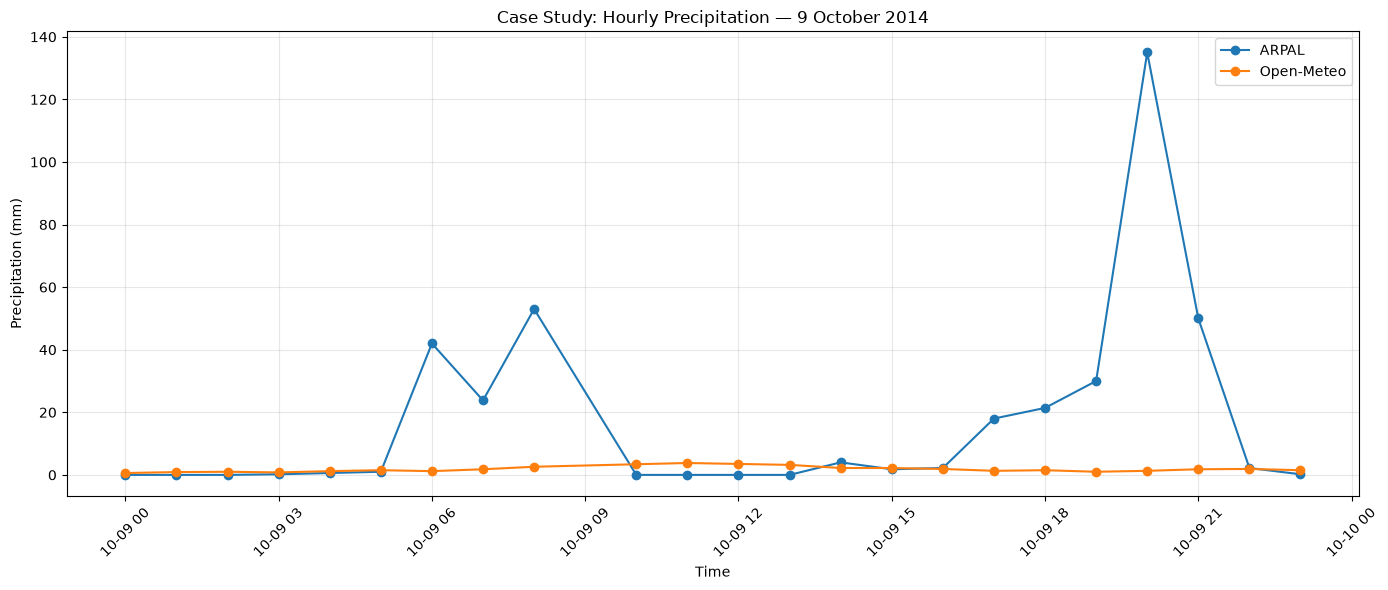

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    oct9["time"],
    oct9["arpal_precipitation_mm"],
    marker="o",
    label="ARPAL"
)

plt.plot(
    oct9["time"],
    oct9["openmeteo_precipitation_mm"],
    marker="o",
    label="Open-Meteo"
)

plt.title("Case Study: Hourly Precipitation — 9 October 2014")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_compare = (
    df_compare
    .set_index("time")
    [["arpal_precipitation_mm", "openmeteo_precipitation_mm"]]
    .resample("D")
    .sum()
    .reset_index()
)

daily_compare

,time,arpal_precipitation_mm,openmeteo_precipitation_mm
0,2014-10-08,72.8,16.7
1,2014-10-09,385.4,42.1
2,2014-10-10,173.6,25.9
3,2014-10-11,58.6,10.6
4,2014-10-12,0.4,1.4


In [ ]:
daily_compare["difference_mm"] = (
    daily_compare["arpal_precipitation_mm"]
    - daily_compare["openmeteo_precipitation_mm"]
)

daily_compare["absolute_error_mm"] = (
    daily_compare["difference_mm"].abs()
)

daily_compare

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08,72.8,16.7,56.1,56.1
1,2014-10-09,385.4,42.1,343.3,343.3
2,2014-10-10,173.6,25.9,147.7,147.7
3,2014-10-11,58.6,10.6,48.0,48.0
4,2014-10-12,0.4,1.4,-1.0,1.0


In [ ]:
daily_mae = daily_compare["absolute_error_mm"].mean()

daily_bias = daily_compare["difference_mm"].mean()

print(f"Daily MAE: {daily_mae:.2f} mm")
print(f"Daily Mean Bias: {daily_bias:.2f} mm")

Daily MAE: 119.22 mm
Daily Mean Bias: 118.82 mm


In [ ]:
extreme_threshold = 20

extreme_events = df_compare[
    df_compare["arpal_precipitation_mm"] >= extreme_threshold
].copy()

print("Number of extreme rainfall hours:", len(extreme_events))

extreme_events[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm"
    ]
]

Number of extreme rainfall hours: 12


,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm
20,2014-10-08 20:00:00,41.4,0.6,40.8
30,2014-10-09 06:00:00,42.0,1.2,40.8
31,2014-10-09 07:00:00,23.8,1.8,22.0
32,2014-10-09 08:00:00,53.0,2.6,50.4
41,2014-10-09 18:00:00,21.4,1.5,19.9
42,2014-10-09 19:00:00,30.0,1.0,29.0
43,2014-10-09 20:00:00,135.0,1.3,133.7
44,2014-10-09 21:00:00,50.0,1.8,48.2
55,2014-10-10 08:00:00,56.8,0.6,56.2
57,2014-10-10 10:00:00,43.2,0.5,42.7


In [ ]:
def classify_rainfall(mm):
    if mm >= 100:
        return "Exceptional"
    elif mm >= 50:
        return "Very Heavy"
    else:
        return "Heavy"


extreme_events["severity"] = (
    extreme_events["arpal_precipitation_mm"]
    .apply(classify_rainfall)
)

extreme_events[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm",
        "severity"
    ]
]

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,severity
20,2014-10-08 20:00:00,41.4,0.6,40.8,Heavy
30,2014-10-09 06:00:00,42.0,1.2,40.8,Heavy
31,2014-10-09 07:00:00,23.8,1.8,22.0,Heavy
32,2014-10-09 08:00:00,53.0,2.6,50.4,Very Heavy
41,2014-10-09 18:00:00,21.4,1.5,19.9,Heavy
42,2014-10-09 19:00:00,30.0,1.0,29.0,Heavy
43,2014-10-09 20:00:00,135.0,1.3,133.7,Exceptional
44,2014-10-09 21:00:00,50.0,1.8,48.2,Very Heavy
55,2014-10-10 08:00:00,56.8,0.6,56.2,Very Heavy
57,2014-10-10 10:00:00,43.2,0.5,42.7,Heavy


In [ ]:
severity_summary = (
    extreme_events
    .groupby("severity")
    .agg(
        hours=("arpal_precipitation_mm", "count"),
        max_rainfall=("arpal_precipitation_mm", "max"),
        mean_rainfall=("arpal_precipitation_mm", "mean"),
        mean_openmeteo=("openmeteo_precipitation_mm", "mean"),
        mean_difference=("difference_mm", "mean")
    )
    .reindex(["Heavy", "Very Heavy", "Exceptional"])
)

severity_summary

,hours,max_rainfall,mean_rainfall,mean_openmeteo,mean_difference
severity,,,,,
Heavy,8,43.2,32.000000,0.950000,31.05
Very Heavy,3,56.8,53.266667,1.666667,51.60
Exceptional,1,135.0,135.000000,1.300000,133.70


In [18]:
df_openmeteo["time"] = pd.to_datetime(df_openmeteo["time"])

In [19]:
df_compare = pd.merge(
    df_arpal[["Inizio rilevazione", "Valore"]],
    df_openmeteo[["time", "precipitation (mm)"]],
    left_on="Inizio rilevazione",
    right_on="time",
    how="inner"
)

df_compare = df_compare.rename(
    columns={
        "Inizio rilevazione": "time",
        "Valore": "arpal_precipitation_mm",
        "precipitation (mm)": "openmeteo_precipitation_mm"
    }
)

df_compare = df_compare[
    ["time", "arpal_precipitation_mm", "openmeteo_precipitation_mm"]
]

df_compare["difference_mm"] = (
    df_compare["arpal_precipitation_mm"]
    - df_compare["openmeteo_precipitation_mm"]
)

df_compare["absolute_error_mm"] = (
    df_compare["difference_mm"].abs()
)

print("Matched hours:", len(df_compare))
df_compare.head()

Matched hours: 107


,time,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08 00:00:00,2014-10-08 00:00:00,0.0,1.0,-1.0,1.0
1,2014-10-08 01:00:00,2014-10-08 01:00:00,0.0,1.3,-1.3,1.3
2,2014-10-08 02:00:00,2014-10-08 02:00:00,0.0,1.5,-1.5,1.5
3,2014-10-08 03:00:00,2014-10-08 03:00:00,0.6,1.5,-0.9,0.9
4,2014-10-08 04:00:00,2014-10-08 04:00:00,0.0,1.5,-1.5,1.5


In [20]:
df_compare = pd.merge(
    df_arpal[["Inizio rilevazione", "Valore"]].rename(
        columns={
            "Inizio rilevazione": "time",
            "Valore": "arpal_precipitation_mm"
        }
    ),
    df_openmeteo[["time", "precipitation (mm)"]].rename(
        columns={
            "precipitation (mm)": "openmeteo_precipitation_mm"
        }
    ),
    on="time",
    how="inner"
)

df_compare["difference_mm"] = (
    df_compare["arpal_precipitation_mm"]
    - df_compare["openmeteo_precipitation_mm"]
)

df_compare["absolute_error_mm"] = (
    df_compare["difference_mm"].abs()
)

print("Matched hours:", len(df_compare))
print(df_compare.columns.tolist())

df_compare.head()

Matched hours: 107
['time', 'arpal_precipitation_mm', 'openmeteo_precipitation_mm', 'difference_mm', 'absolute_error_mm']


,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08 00:00:00,0.0,1.0,-1.0,1.0
1,2014-10-08 01:00:00,0.0,1.3,-1.3,1.3
2,2014-10-08 02:00:00,0.0,1.5,-1.5,1.5
3,2014-10-08 03:00:00,0.6,1.5,-0.9,0.9
4,2014-10-08 04:00:00,0.0,1.5,-1.5,1.5


In [21]:
extreme_threshold = 20

extreme_events = df_compare[
    df_compare["arpal_precipitation_mm"] >= extreme_threshold
].copy()

print("Number of extreme rainfall hours:", len(extreme_events))

extreme_events[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm"
    ]
].sort_values(
    "arpal_precipitation_mm",
    ascending=False
)

Number of extreme rainfall hours: 12


,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm
43,2014-10-09 20:00:00,135.0,1.3,133.7
55,2014-10-10 08:00:00,56.8,0.6,56.2
32,2014-10-09 08:00:00,53.0,2.6,50.4
44,2014-10-09 21:00:00,50.0,1.8,48.2
57,2014-10-10 10:00:00,43.2,0.5,42.7
30,2014-10-09 06:00:00,42.0,1.2,40.8
20,2014-10-08 20:00:00,41.4,0.6,40.8
71,2014-10-11 01:00:00,32.8,0.5,32.3
42,2014-10-09 19:00:00,30.0,1.0,29.0
31,2014-10-09 07:00:00,23.8,1.8,22.0


In [22]:
def classify_rainfall(mm):
    if mm >= 100:
        return "Exceptional"
    elif mm >= 50:
        return "Very Heavy"
    else:
        return "Heavy"


extreme_events["severity"] = (
    extreme_events["arpal_precipitation_mm"]
    .apply(classify_rainfall)
)

extreme_events[
    [
        "time",
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm",
        "severity"
    ]
]

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,severity
20,2014-10-08 20:00:00,41.4,0.6,40.8,Heavy
30,2014-10-09 06:00:00,42.0,1.2,40.8,Heavy
31,2014-10-09 07:00:00,23.8,1.8,22.0,Heavy
32,2014-10-09 08:00:00,53.0,2.6,50.4,Very Heavy
41,2014-10-09 18:00:00,21.4,1.5,19.9,Heavy
42,2014-10-09 19:00:00,30.0,1.0,29.0,Heavy
43,2014-10-09 20:00:00,135.0,1.3,133.7,Exceptional
44,2014-10-09 21:00:00,50.0,1.8,48.2,Very Heavy
55,2014-10-10 08:00:00,56.8,0.6,56.2,Very Heavy
57,2014-10-10 10:00:00,43.2,0.5,42.7,Heavy


In [23]:
severity_summary = (
    extreme_events
    .groupby("severity")
    .agg(
        hours=("arpal_precipitation_mm", "count"),
        max_rainfall=("arpal_precipitation_mm", "max"),
        mean_rainfall=("arpal_precipitation_mm", "mean"),
        mean_openmeteo=("openmeteo_precipitation_mm", "mean"),
        mean_difference=("difference_mm", "mean")
    )
)

severity_summary

,hours,max_rainfall,mean_rainfall,mean_openmeteo,mean_difference
severity,,,,,
Exceptional,1,135.0,135.000000,1.300000,133.70
Heavy,8,43.2,32.000000,0.950000,31.05
Very Heavy,3,56.8,53.266667,1.666667,51.60


NameError: name 'plt' is not defined

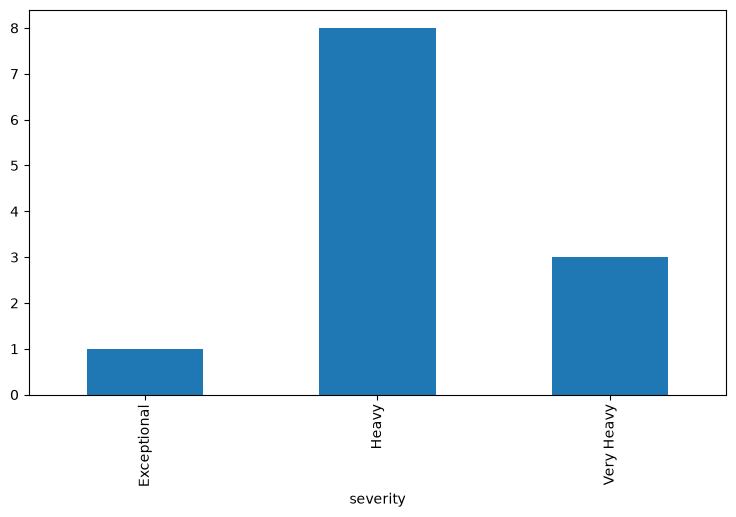

In [24]:
severity_summary["hours"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Extreme Rainfall Events by Severity")
plt.xlabel("Rainfall Severity")
plt.ylabel("Number of Hours")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

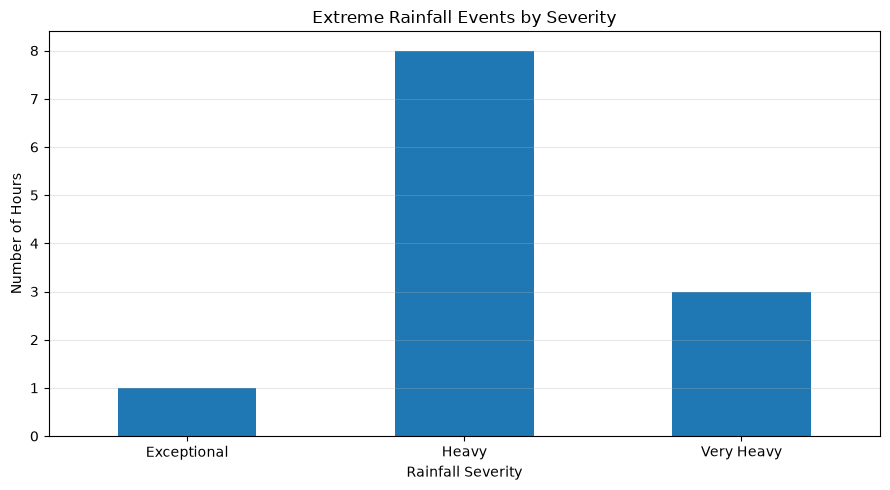

In [25]:
import matplotlib.pyplot as plt

severity_summary["hours"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Extreme Rainfall Events by Severity")
plt.xlabel("Rainfall Severity")
plt.ylabel("Number of Hours")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
severity_error = (
    extreme_events
    .groupby("severity")
    .agg(
        mean_error=("difference_mm", "mean"),
        mean_absolute_error=("difference_mm", lambda x: x.abs().mean())
    )
)

severity_error

,mean_error,mean_absolute_error
severity,,
Exceptional,133.70,133.70
Heavy,31.05,31.05
Very Heavy,51.60,51.60


In [27]:
print("===== FINAL SUMMARY =====")

print(f"Matched hours: {len(df_compare)}")

print(f"Overall MAE: {df_compare['absolute_error_mm'].mean():.2f} mm")

print(f"Overall Mean Bias: {df_compare['difference_mm'].mean():.2f} mm")

print(f"Overall RMSE: {(df_compare['difference_mm'] ** 2).mean() ** 0.5:.2f} mm")

print(f"Extreme rainfall hours: {len(extreme_events)}")

print("\nSeverity distribution:")
print(extreme_events["severity"].value_counts())

print("\nMean error by severity:")
print(severity_error)

===== FINAL SUMMARY =====
Matched hours: 107
Overall MAE: 6.64 mm
Overall Mean Bias: 5.55 mm
Overall RMSE: 18.27 mm
Extreme rainfall hours: 12

Severity distribution:
severity
Heavy          8
Very Heavy     3
Exceptional    1
Name: count, dtype: int64

Mean error by severity:
             mean_error  mean_absolute_error
severity                                    
Exceptional      133.70               133.70
Heavy             31.05                31.05
Very Heavy        51.60                51.60


In [28]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_compare.to_csv(
    "../data/processed/precipitation_comparison.csv",
    index=False
)

print("Saved: precipitation_comparison.csv")

Saved: precipitation_comparison.csv


In [29]:
extreme_events.to_csv(
    "../data/processed/extreme_rainfall_events.csv",
    index=False
)

print("Saved: extreme_rainfall_events.csv")

Saved: extreme_rainfall_events.csv


In [30]:
severity_summary.to_csv(
    "../data/processed/severity_summary.csv"
)

print("Saved: severity_summary.csv")

Saved: severity_summary.csv
